In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [50]:
df_students= pd.read_csv("C:/Users/thiru/Downloads/archive(4)/indian_engineering_student_placement.csv")
df_targets= pd.read_csv("C:/Users/thiru/Downloads/archive(4)/placement_targets.csv")

In [51]:
df=pd.merge(df_students, df_targets, how="left")
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [52]:
df.shape

(5000, 25)

In [53]:
df["branch"].nunique()

5

In [54]:
df["branch"].unique()

array(['ECE', 'IT', 'CSE', 'CE', 'ME'], dtype=object)

In [55]:
df["branch"].value_counts()

branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64

In [56]:
df["gender"].nunique()

2

In [57]:
df["gender"].value_counts()

gender
Male      2999
Female    2001
Name: count, dtype: int64

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [59]:
df.columns

Index(['Student_ID', 'gender', 'branch', 'cgpa', 'tenth_percentage',
       'twelfth_percentage', 'backlogs', 'study_hours_per_day',
       'attendance_percentage', 'projects_completed', 'internships_completed',
       'coding_skill_rating', 'communication_skill_rating',
       'aptitude_skill_rating', 'hackathons_participated',
       'certifications_count', 'sleep_hours', 'stress_level', 'part_time_job',
       'family_income_level', 'city_tier', 'internet_access',
       'extracurricular_involvement', 'placement_status', 'salary_lpa'],
      dtype='object')

In [60]:
df.isnull().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
placement_status                  0
salary_lpa                        0
dtype: int64

In [61]:
df.nunique()

Student_ID                     5000
gender                            2
branch                            5
cgpa                            451
tenth_percentage                478
twelfth_percentage              479
backlogs                          6
study_hours_per_day              99
attendance_percentage           414
projects_completed                9
internships_completed             5
coding_skill_rating               5
communication_skill_rating        5
aptitude_skill_rating             5
hackathons_participated           7
certifications_count             10
sleep_hours                      51
stress_level                     10
part_time_job                     2
family_income_level               3
city_tier                         3
internet_access                   2
extracurricular_involvement       3
placement_status                  2
salary_lpa                     1052
dtype: int64

In [62]:
df.describe()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [63]:
df["extracurricular_involvement"]=df["extracurricular_involvement"].fillna("NA")

In [64]:
df["extracurricular_involvement"].isna().sum()

0

<Axes: xlabel='tenth_percentage'>

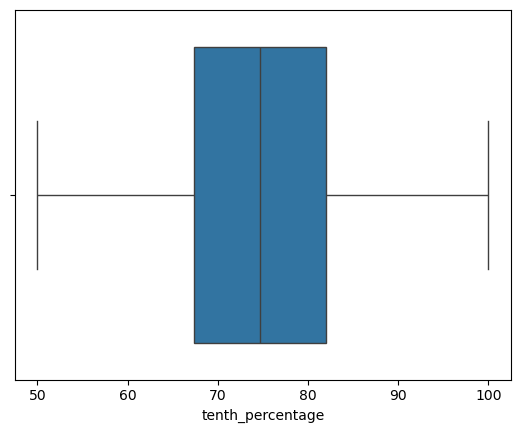

In [65]:
sn.boxplot(x='tenth_percentage',data=df)

<Axes: xlabel='twelfth_percentage'>

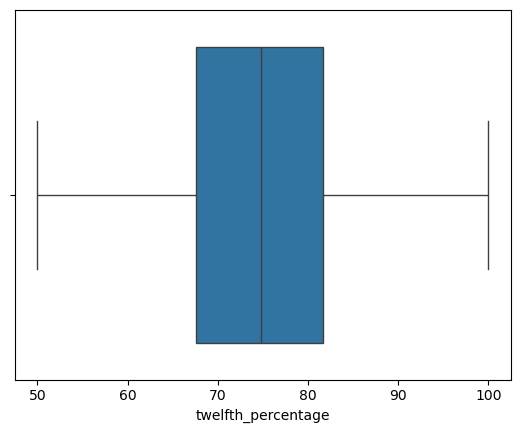

In [66]:
sn.boxplot(x='twelfth_percentage',data=df)

<Axes: xlabel='communication_skill_rating'>

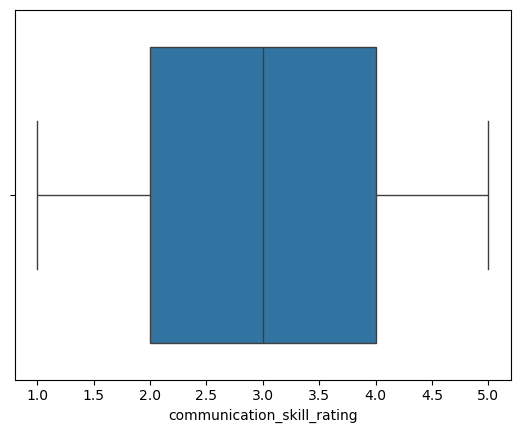

In [67]:
sn.boxplot(x='communication_skill_rating',data=df)

<Axes: xlabel='coding_skill_rating'>

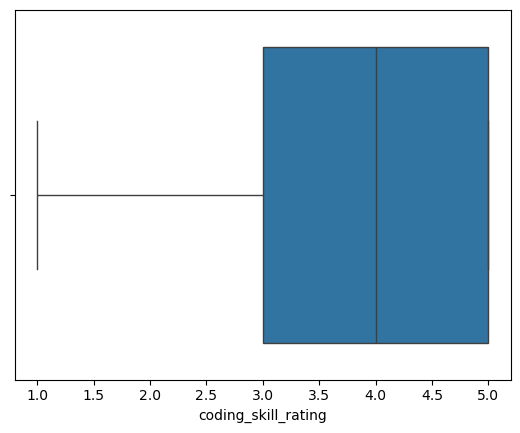

In [68]:
sn.boxplot(x='coding_skill_rating',data=df)

<Axes: xlabel='aptitude_skill_rating'>

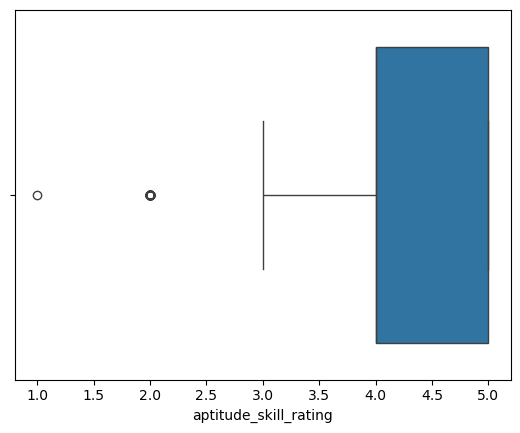

In [69]:
sn.boxplot(x='aptitude_skill_rating',data=df)

<Axes: xlabel='study_hours_per_day'>

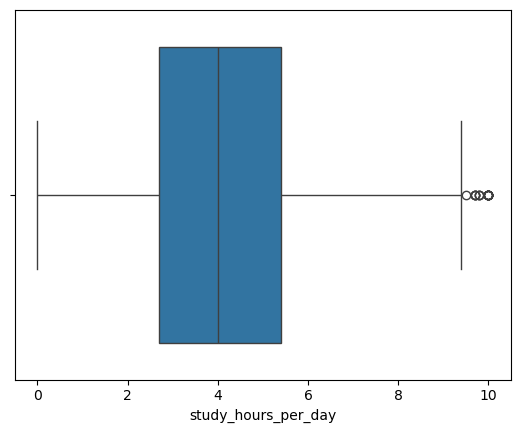

In [70]:
sn.boxplot(x='study_hours_per_day',data=df)

<Axes: xlabel='sleep_hours'>

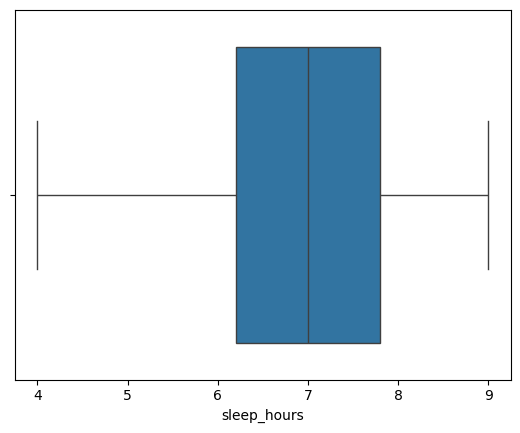

In [71]:
sn.boxplot(x='sleep_hours',data=df)

# Data Visulization

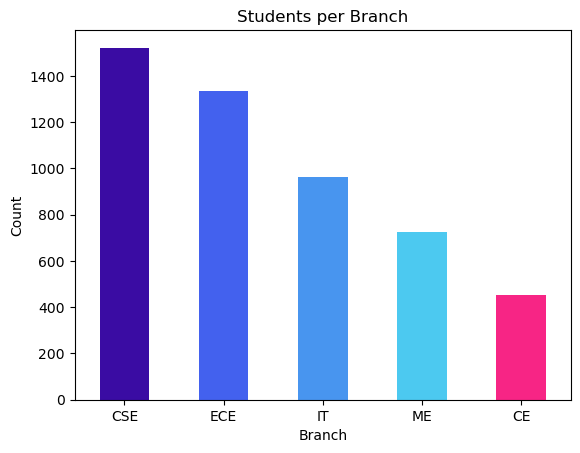

In [72]:
df["branch"].value_counts().plot(kind="bar",color=["#3A0CA3", "#4361EE", "#4895EF", "#4CC9F0", "#F72585"])
plt.title("Students per Branch")
plt.xlabel("Branch")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

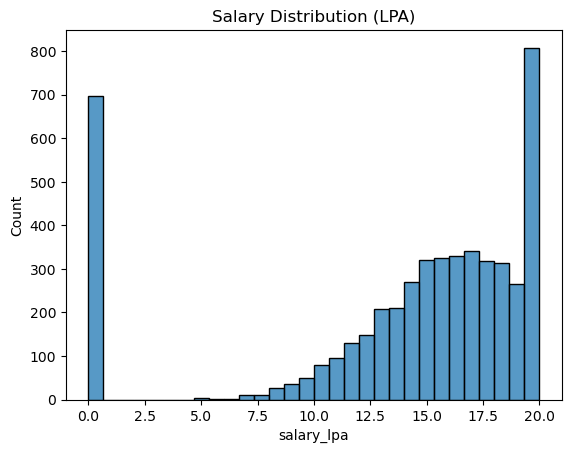

In [73]:
sn.histplot(df["salary_lpa"])
plt.title("Salary Distribution (LPA)")
plt.show()

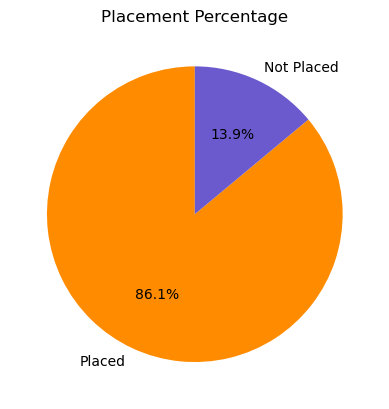

In [74]:
df["placement_status"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=["#FF8C00", "#6A5ACD"])
plt.ylabel("")
plt.title("Placement Percentage")
plt.show()

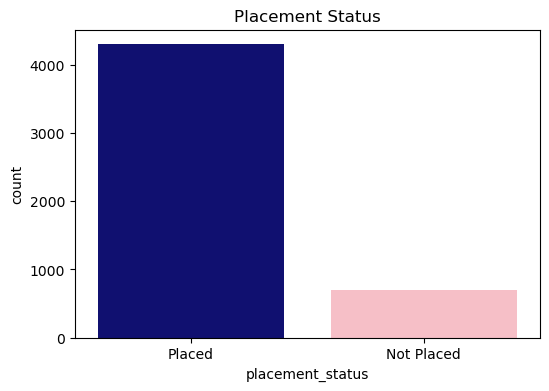

In [75]:
plt.figure(figsize=(6,4))
sn.countplot(data=df, x='placement_status',hue='placement_status',palette=["#000080", "#FFB6C1"])
plt.title('Placement Status')
plt.show()

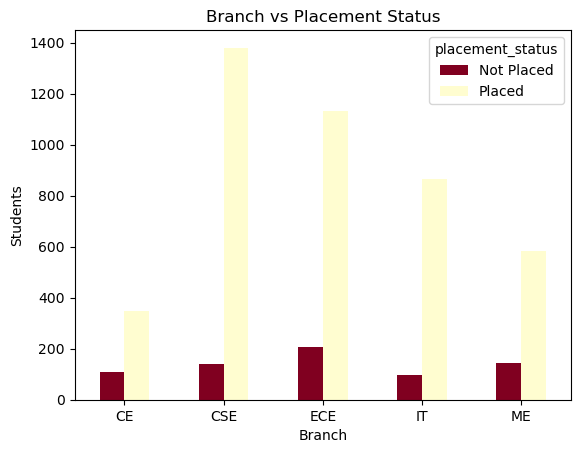

In [76]:
branch_place = pd.crosstab(df["branch"],df["placement_status"])
branch_place.plot(kind="bar",color=["#800020", "#FFFDD0"])
plt.title("Branch vs Placement Status")
plt.xlabel("Branch")
plt.ylabel("Students")
plt.xticks(rotation=0)
plt.show()

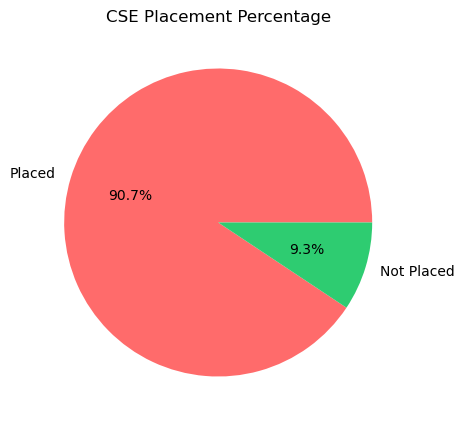

In [77]:
cse = df[df["branch"] == "CSE"]
cse_percent = cse["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(cse_percent,labels=cse_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("CSE Placement Percentage")
plt.show()

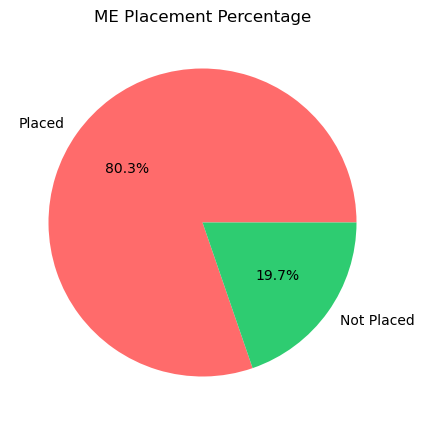

In [78]:
me = df[df["branch"] == "ME"]
me_percent = me["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(me_percent,labels=me_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("ME Placement Percentage")
plt.show()

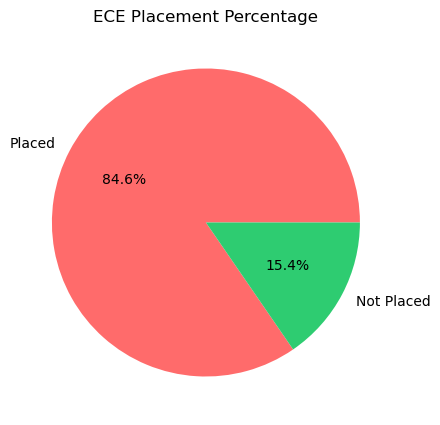

In [79]:
ece = df[df["branch"] == "ECE"]
ece_percent = ece["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(ece_percent,labels=ece_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("ECE Placement Percentage")
plt.show()

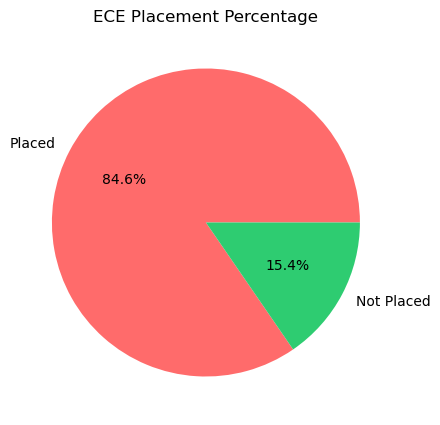

In [80]:
ece = df[df["branch"] == "ECE"]
ece_percent = ece["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(ece_percent,labels=ece_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("ECE Placement Percentage")
plt.show()

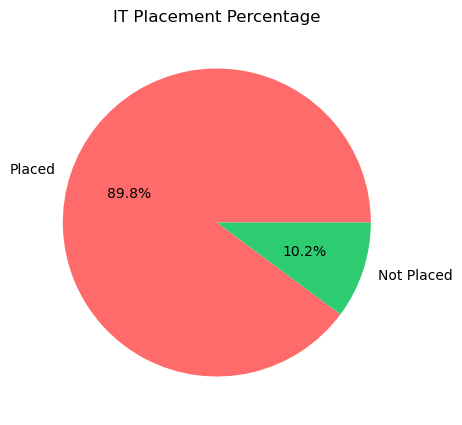

In [81]:
it = df[df["branch"] == "IT"]
ece_percent = it["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(ece_percent,labels=ece_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("IT Placement Percentage")
plt.show()

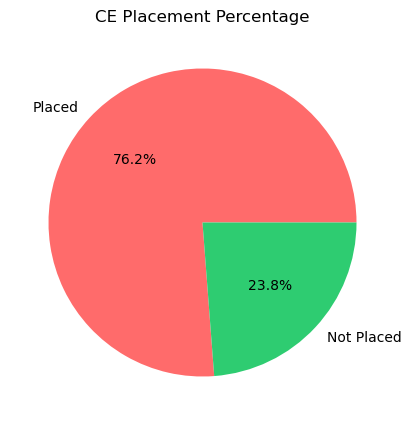

In [82]:
ce = df[df["branch"] == "CE"]
ece_percent = ce["placement_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(ece_percent,labels=ece_percent.index,autopct="%1.1f%%",colors=["#FF6B6B", "#2ECC71"])
plt.title("CE Placement Percentage")
plt.show()

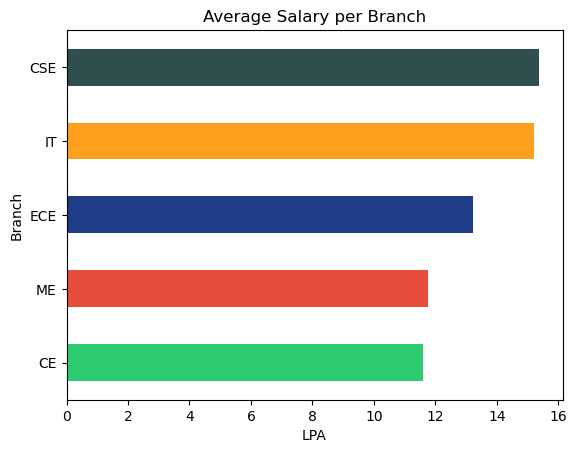

In [83]:
df.groupby("branch")["salary_lpa"].mean().sort_values().plot(kind="barh",color=["#2ECC71", "#E74C3C","#1F3C88", "#FF9F1C","#2F4F4F"])
plt.title("Average Salary per Branch")
plt.xlabel("LPA")
plt.ylabel("Branch")
plt.show()

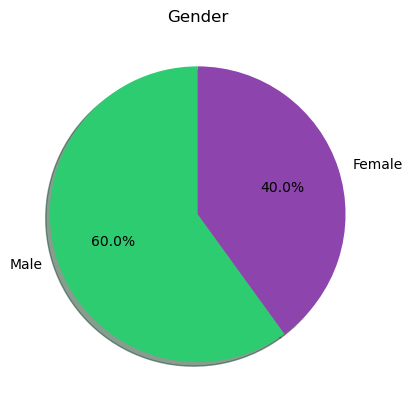

In [84]:
df["gender"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=["#2ECC71", "#8E44AD"],shadow=True)
plt.ylabel("")
plt.title("Gender")
plt.show()

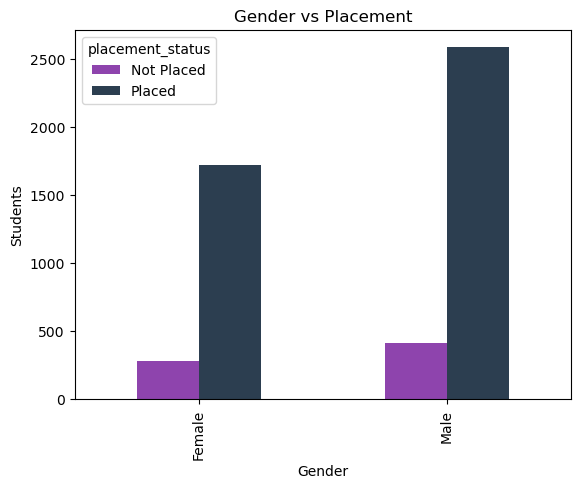

In [85]:
pd.crosstab(df["gender"], df["placement_status"]).plot(kind="bar",color=["#8E44AD", "#2C3E50"])
plt.title("Gender vs Placement")
plt.xlabel("Gender")
plt.ylabel("Students")
plt.show()

<Figure size 2000x1000 with 0 Axes>

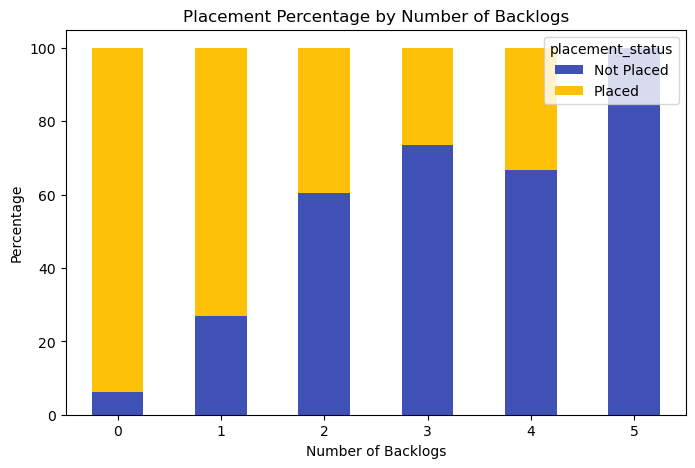

In [86]:
backlog_percent = pd.crosstab(df["backlogs"],df["placement_status"],normalize="index") * 100
plt.figure(figsize=(20,10))
backlog_percent.plot(kind="bar",stacked=True,figsize=(8,5),color=["#3F51B5", "#FFC107"])
plt.title("Placement Percentage by Number of Backlogs")
plt.xlabel("Number of Backlogs")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [87]:
pd.crosstab(df["backlogs"], df["placement_status"])

placement_status,Not Placed,Placed
backlogs,,
0,223,3380
1,303,820
2,140,92
3,28,10
4,2,1
5,1,0


In [88]:
df["cgpa_group"] = "Below 7"

df.loc[(df["cgpa"] >= 7) & (df["cgpa"] <= 8.5), "cgpa_group"] = "7 - 8.5"

df.loc[df["cgpa"] > 8.5, "cgpa_group"] = "Above 8.5"


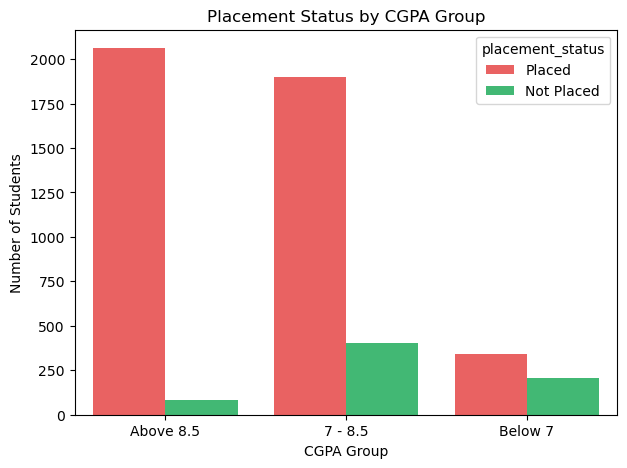

In [89]:
plt.figure(figsize=(7,5))
sn.countplot(data=df, x="cgpa_group",hue="placement_status",palette=["#FF4C4C", "#2ECC71"])
plt.title("Placement Status by CGPA Group")
plt.xlabel("CGPA Group")
plt.ylabel("Number of Students")
plt.show()

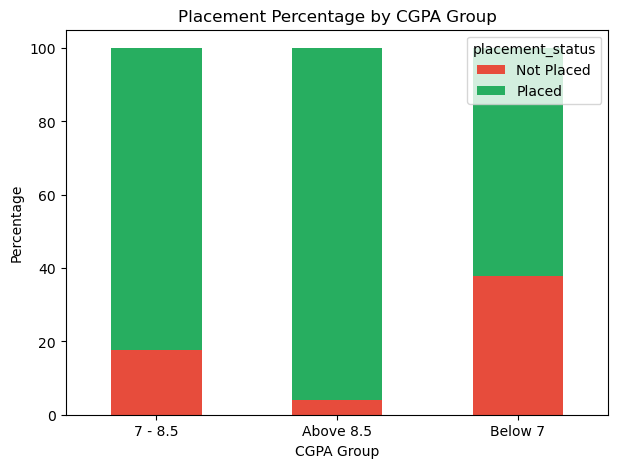

In [90]:
cgpa_percent = pd.crosstab(df["cgpa_group"], df["placement_status"], normalize="index") * 100

cgpa_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    color=["#E74C3C", "#27AE60"]
)

plt.title("Placement Percentage by CGPA Group")
plt.xlabel("CGPA Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


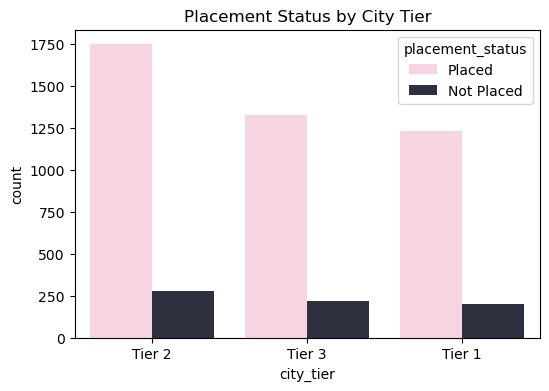

In [91]:
plt.figure(figsize=(6,4))
sn.countplot(data=df, x='city_tier', hue='placement_status',palette=["#FDCEDF", "#2B2D42"])
plt.title('Placement Status by City Tier')
plt.show()

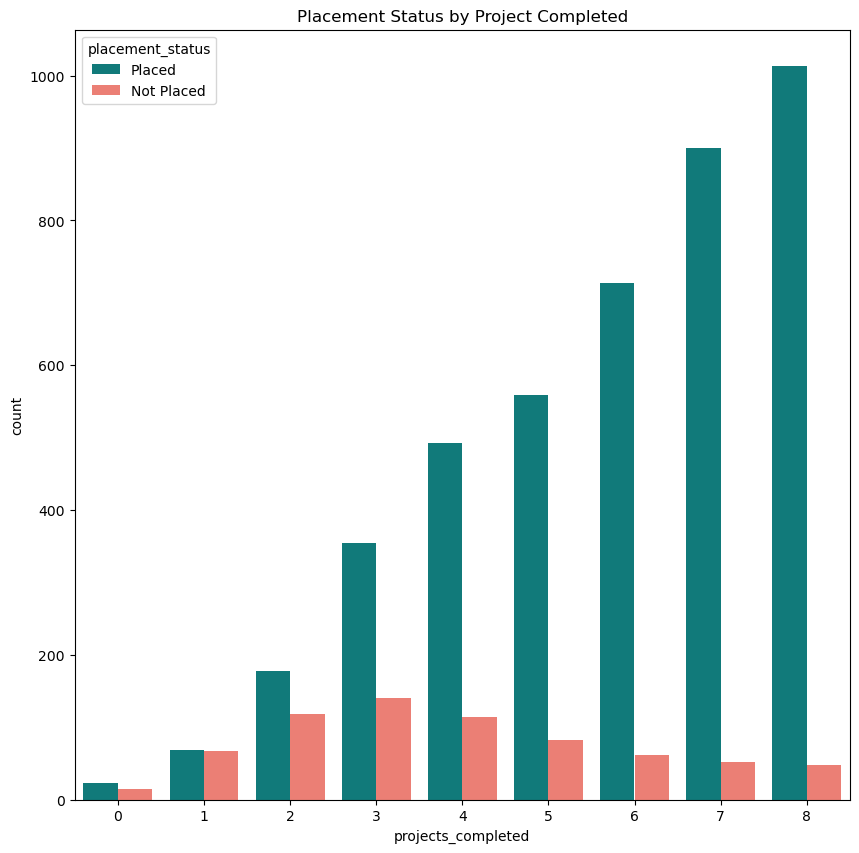

In [92]:
plt.figure(figsize=(10,10))
sn.countplot(data=df, x='projects_completed',hue='placement_status',palette=["#008B8B", "#FF6F61"])
plt.title('Placement Status by Project Completed')
plt.show()

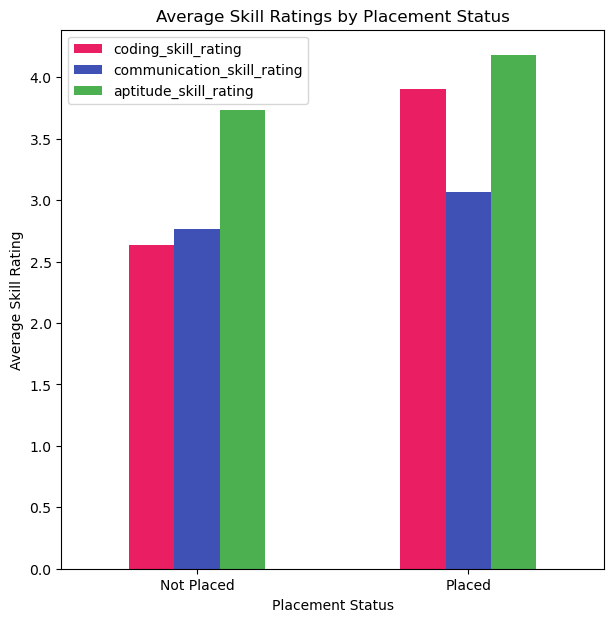

In [93]:
df1=df.groupby("placement_status")[["coding_skill_rating","communication_skill_rating","aptitude_skill_rating"]].mean()
df1.plot(kind="bar",figsize=(7,7),color=["#E91E63", "#3F51B5", "#4CAF50"])
plt.title("Average Skill Ratings by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Skill Rating")
plt.xticks(rotation=0)
plt.show()

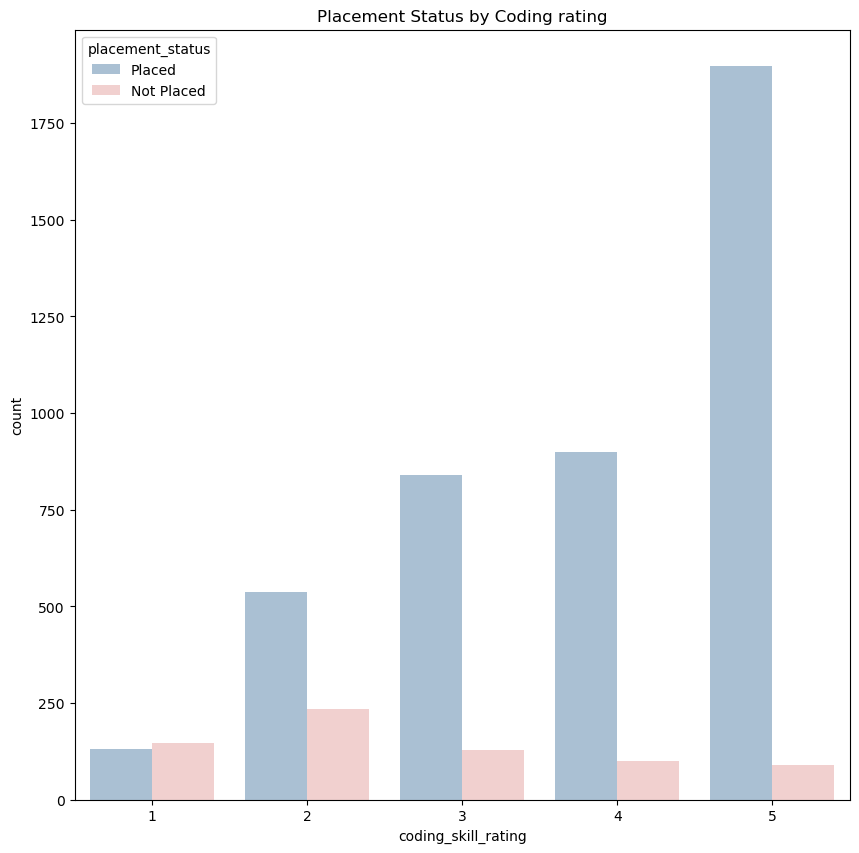

In [94]:
plt.figure(figsize=(10,10))
sn.countplot(data=df, x='coding_skill_rating',hue='placement_status',palette=["#A3C1DA", "#F7CAC9"])
plt.title('Placement Status by Coding rating')
plt.show()

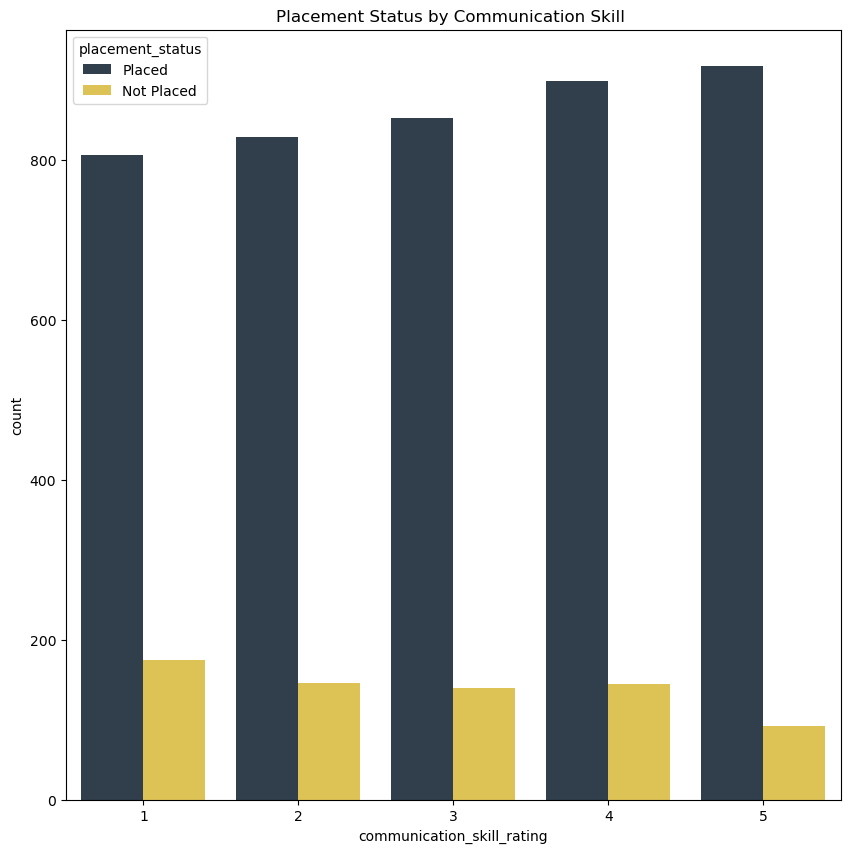

In [95]:
plt.figure(figsize=(10,10))
sn.countplot(data=df, x='communication_skill_rating',hue='placement_status',palette=["#2C3E50", "#F4D03F"])
plt.title('Placement Status by Communication Skill ')
plt.show()

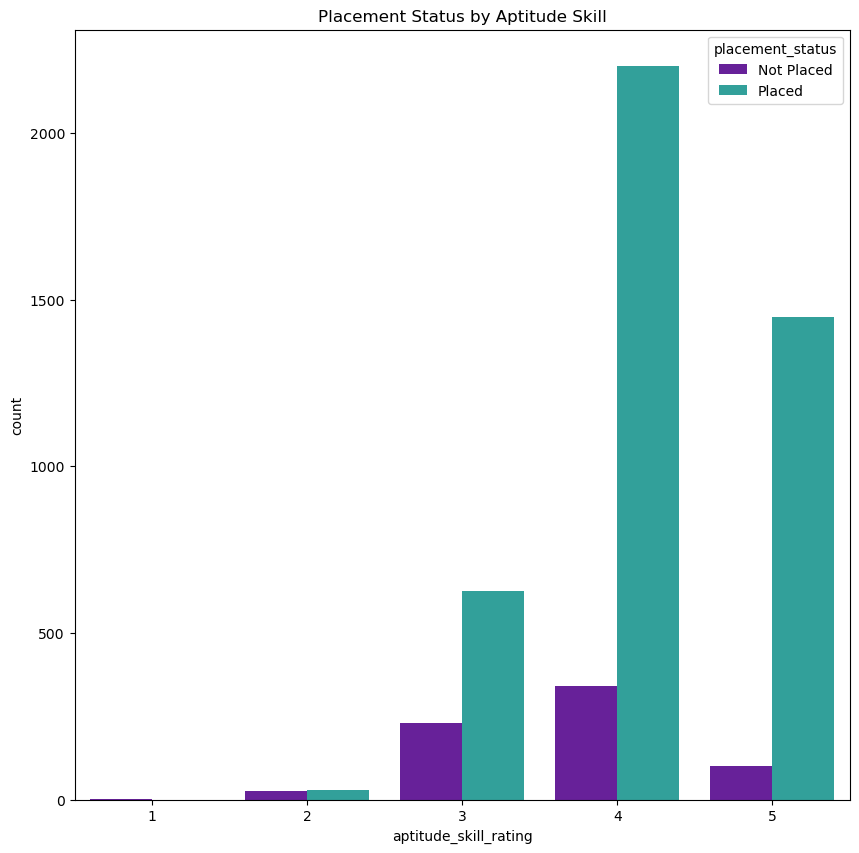

In [96]:
plt.figure(figsize=(10,10))
sn.countplot(data=df, x='aptitude_skill_rating', hue='placement_status',palette=["#6A0DAD", "#20B2AA"])
plt.title('Placement Status by Aptitude Skill')
plt.show()

# Summary

1. Higher coding, communication, and aptitude skills increase the likelihood of placement.

2. Coding skill has the strongest influence on placement, followed by aptitude and communication.

3. Low ratings in these skills, especially across all three, correlate with being not placed.

4. Placement chances improve significantly for students with above-average scores in at least two skills.

5. All three skills are important, but coding and aptitude tend to play a slightly bigger role than communication.

6. lesser the backlogs higher chances of placement possibility
